In [ ]:
# Install required packages
!pip install requests beautifulsoup4 nltk gensim scikit-learn

# Download NLTK data
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.2 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import re
import math
import json
import random
from collections import Counter
from typing import List, Tuple, Dict

import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

WIKI_URL = "https://en.wikipedia.org/wiki/The_Lord_of_the_Rings"
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [ ]:
def ensure_nltk():
    resources = ["punkt", "punkt_tab"]
    for r in resources:
        try:
            nltk.data.find(f"tokenizers/{r}")
        except LookupError:
            nltk.download(r)

ensure_nltk()
print("NLTK resources ready.")

NLTK resources ready.


In [ ]:
def fetch_wikipedia_article(url: str) -> str:
    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; SGNS-LOTR-Training/1.0)"
    }
    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()

    # Extract main content text from the Wikipedia page
    soup = BeautifulSoup(resp.text, "html.parser")

    content_div = soup.find("div", {"id": "mw-content-text"})
    if content_div is None:
        raise ValueError("Could not find Wikipedia article content.")

    paragraphs = content_div.find_all(["p", "li"])
    text_blocks = []

    for p in paragraphs:
        txt = p.get_text(" ", strip=True)
        if txt:
            text_blocks.append(txt)

    text = "\n".join(text_blocks)

    text = re.sub(r"\[[0-9]+\]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

print("Downloading Wikipedia article...")
raw_text = fetch_wikipedia_article(WIKI_URL)
print(f"Raw text length: {len(raw_text)} characters")
print(f"\nFirst 800 characters:\n{'-'*50}")
print(raw_text[:800])
print('-'*50)

Raw text length: 92927 characters

First 800 characters:
--------------------------------------------------
High fantasy Adventure 29 July 1954 ( The Fellowship of the Ring ) 11 November 1954 ( The Two Towers ) 20 October 1955 ( The Return of the King ) The Lord of the Rings is an epic [ 1 ] high fantasy novel [ a ] written by the English author and scholar J. R. R. Tolkien . Set in Middle-earth , the story began as a sequel to Tolkien's 1937 children's book The Hobbit but eventually developed into a much larger work. Written in stages between 1937 and 1949 , The Lord of the Rings is one of the best-selling books ever written , with over 150 million copies sold. [ 2 ] The title refers to the story's main antagonist , [ b ] the Dark Lord Sauron , who in an earlier age created the One Ring , allowing him to rule the other Rings of Power given to men , dwarves , and elves , in his campaign to conqu
--------------------------------------------------


In [ ]:
def preprocess_text(text: str) -> List[List[str]]:
    sentences = sent_tokenize(text)

    processed = []
    for sent in sentences:
        sent = sent.lower()
        sent = re.sub(r"[^a-z0-9\-\s]", " ", sent)
        sent = re.sub(r"\s+", " ", sent).strip()
        if not sent:
            continue

        tokens = word_tokenize(sent)

        cleaned = []
        for tok in tokens:
            tok = tok.strip("-")
            if not tok:
                continue
            if tok.isdigit():
                continue
            if len(tok) < 2:
                continue
            cleaned.append(tok)

        if len(cleaned) >= 3:
            processed.append(cleaned)

    return processed

def corpus_stats(sentences: List[List[str]]) -> Dict[str, int]:
    flat = [w for s in sentences for w in s]
    vocab = set(flat)
    return {
        "num_sentences": len(sentences),
        "num_tokens": len(flat),
        "vocab_size": len(vocab),
    }

print("Preprocessing text...")
sentences = preprocess_text(raw_text)
stats = corpus_stats(sentences)

print("\n=== Corpus Stats ===")
for k, v in stats.items():
    print(f"{k}: {v}")

print(f"\nFirst 3 sentences (first 15 tokens each):")
for i, s in enumerate(sentences[:3]):
    print(f"  {i+1}. {s[:15]}...")

Preprocessing text...

=== Corpus Stats ===
num_sentences: 713
num_tokens: 12441
vocab_size: 2932

First 3 sentences (first 15 tokens each):
  1. ['high', 'fantasy', 'adventure', 'july', 'the', 'fellowship', 'of', 'the', 'ring', 'november', 'the', 'two', 'towers', 'october', 'the']...
  2. ['set', 'in', 'middle-earth', 'the', 'story', 'began', 'as', 'sequel', 'to', 'tolkien', 'children', 'book', 'the', 'hobbit', 'but']...
  3. ['written', 'in', 'stages', 'between', 'and', 'the', 'lord', 'of', 'the', 'rings', 'is', 'one', 'of', 'the', 'best-selling']...


In [ ]:
def train_sgns(sentences: List[List[str]], window=5, vector_size=100) -> Word2Vec:
    model = Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=window,
        min_count=1,
        workers=4,
        sg=1,          # 0 = CBOW, 1 = skip-gram
        negative=10,   # negative sampling
        epochs=200,
        sample=1e-3,
        alpha=0.025,
        min_alpha=0.0007,
        seed=RANDOM_SEED,
    )
    return model

print("Training OLD Skip-gram with Negative Sampling...")
print("Configuration: vector_size=100, window=5, sg=1, negative=10, epochs=200")
print("-" * 50)

model_old = train_sgns(sentences, window=5, vector_size=100)

print(f"\nVocabulary size learned: {len(model_old.wv)}")
print(f"Vector dimension: {model_old.wv.vector_size}")
print(f"Window size: 5")
print(f"Architecture: Skip-gram (sg=1)")
print(f"Negative samples: 10")

Training OLD Skip-gram with Negative Sampling...
Configuration: vector_size=100, window=5, sg=1, negative=10, epochs=200
--------------------------------------------------

Vocabulary size learned: 2932
Vector dimension: 100
Window size: 5
Architecture: Skip-gram (sg=1)
Negative samples: 10


In [ ]:
# Helper functions

def has_word(model: Word2Vec, word: str) -> bool:
    return word in model.wv.key_to_index


def cosine(model: Word2Vec, w1: str, w2: str) -> float:
    v1 = model.wv[w1].reshape(1, -1)
    v2 = model.wv[w2].reshape(1, -1)
    return float(cosine_similarity(v1, v2)[0][0])


def evaluate_relatedness(model: Word2Vec, test_pairs: List[Tuple[str, str, float]]):
    gold = []
    pred = []
    covered = []

    for w1, w2, score in test_pairs:
        if has_word(model, w1) and has_word(model, w2):
            sim = cosine(model, w1, w2)
            gold.append(score)
            pred.append(sim)
            covered.append((w1, w2, score, sim))

    return {
        "covered_items": covered,
        "coverage": len(covered),
        "total": len(test_pairs),
    }


def evaluate_analogies(model: Word2Vec, analogies: List[Tuple[str, str, str, str]]):
    """
    Analogy format: a:b :: c:d
    Checks whether most_similar(positive=[b,c], negative=[a]) returns d.
    """
    covered = 0
    correct = 0
    details = []

    for a, b, c, d in analogies:
        if all(has_word(model, w) for w in [a, b, c, d]):
            covered += 1
            try:
                preds = model.wv.most_similar(positive=[b, c], negative=[a], topn=5)
                predicted_words = [w for w, _ in preds]
                hit = d in predicted_words
                correct += int(hit)
                details.append({
                    "analogy": f"{a}:{b}::{c}:?",
                    "expected": d,
                    "predictions": predicted_words,
                    "correct_in_top5": hit
                })
            except KeyError:
                pass

    accuracy = correct / covered if covered else float("nan")
    return {
        "coverage": covered,
        "total": len(analogies),
        "accuracy_top5": accuracy,
        "details": details
    }


def print_top_neighbors(model: Word2Vec, words: List[str], topn: int = 8):
    print("\n=== Nearest Neighbors ===")
    for word in words:
        if has_word(model, word):
            neighbors = model.wv.most_similar(word, topn=topn)
            print(f"\n{word}:")
            for neigh, score in neighbors:
                print(f"  {neigh:20s} {score:.4f}")
        else:
            print(f"\n{word}: [OOV]")

In [ ]:
# LOTR-themed probe words
probe_words = [
    "frodo", "gandalf", "aragorn", "ring", "shire",
    "mordor", "elf", "dwarf", "hobbit", "sauron"
]

print("=" * 60)
print("OLD MODEL RESULTS (window=5, vector_size=100)")
print("=" * 60)

print_top_neighbors(model_old, probe_words, topn=8)

OLD MODEL RESULTS (window=5, vector_size=100)

=== Nearest Neighbors ===

frodo:
  blade                0.5210
  athelas              0.5141
  herb                 0.5106
  sam                  0.5096
  she                  0.5031
  cursed               0.5022
  ruin                 0.4982
  venom                0.4968

gandalf:
  say                  0.5878
  farewell             0.5830
  traitor              0.5813
  radagast             0.5634
  wizard               0.5609
  replacing            0.5558
  departs              0.5499
  reports              0.5446

aragorn:
  scouring             0.6500
  daughter             0.6444
  perish               0.6439
  weds                 0.6420
  arwen                0.6323
  wins                 0.6311
  accompanied          0.6296
  conquest             0.6284

ring:
  council              0.5009
  breaking             0.4969
  disappears           0.4900
  treason              0.4885
  khraniteli           0.4838
  silmarils           

In [ ]:
# LOTR-themed relatedness test set
# Higher score = more semantically related
relatedness_test = [
    ("frodo", "sam", 0.95),        # close companions
    ("frodo", "hobbit", 0.90),     # species identity
    ("gandalf", "wizard", 0.95),   # profession
    ("aragorn", "king", 0.85),     # title
    ("ring", "sauron", 0.90),      # object-villain link
    ("elf", "legolas", 0.85),      # species-character
    ("mordor", "sauron", 0.88),    # place-ruler
    ("shire", "hobbit", 0.92),     # home-species
    ("dwarf", "gimli", 0.85),      # species-character
    ("frodo", "kitchen", 0.05),    # unrelated
    ("ring", "tractor", 0.02),     # unrelated
    ("mordor", "shire", 0.30),     # opposite places
    ("elf", "dwarf", 0.50),        # different species
]

rel_results_old = evaluate_relatedness(model_old, relatedness_test)

print("\n=== Relatedness Test Set (OLD MODEL) ===")
print(f"Coverage: {rel_results_old['coverage']}/{rel_results_old['total']}")
print("-" * 50)
for w1, w2, gold, pred in rel_results_old["covered_items"]:
    print(f"{w1:10s} - {w2:10s} | gold={gold:.2f} pred={pred:.4f}")


=== Relatedness Test Set (OLD MODEL) ===
Coverage: 11/13
--------------------------------------------------
frodo      - sam        | gold=0.95 pred=0.5096
frodo      - hobbit     | gold=0.90 pred=0.2380
gandalf    - wizard     | gold=0.95 pred=0.5609
aragorn    - king       | gold=0.85 pred=0.3524
ring       - sauron     | gold=0.90 pred=0.4424
elf        - legolas    | gold=0.85 pred=0.6844
mordor     - sauron     | gold=0.88 pred=0.2528
shire      - hobbit     | gold=0.92 pred=0.3149
dwarf      - gimli      | gold=0.85 pred=0.8109
mordor     - shire      | gold=0.30 pred=0.4294
elf        - dwarf      | gold=0.50 pred=0.7808


In [ ]:
# LOTR-themed analogy test set
analogy_test = [
    ("frodo", "hobbit", "legolas", "elf"),      # character:species
    ("shire", "hobbit", "mordor", "orc"),        # place:inhabitant
    ("gandalf", "wizard", "aragorn", "king"),    # character:title
    ("sam", "frodo", "merry", "pippin"),         # companion pairs
]

analogy_results_old = evaluate_analogies(model_old, analogy_test)

print("\n=== Analogy Test Set (OLD MODEL) ===")
print(f"Coverage: {analogy_results_old['coverage']}/{analogy_results_old['total']}")
print(f"Top-5 accuracy: {analogy_results_old['accuracy_top5']:.2%}")
print("-" * 50)
for item in analogy_results_old["details"]:
    print(json.dumps(item, ensure_ascii=False))


=== Analogy Test Set (OLD MODEL) ===
Coverage: 4/4
Top-5 accuracy: 0.00%
--------------------------------------------------
{"analogy": "frodo:hobbit::legolas:?", "expected": "elf", "predictions": ["niggle", "alliterative", "shellshocked", "gimli", "lay"], "correct_in_top5": false}
{"analogy": "shire:hobbit::mordor:?", "expected": "orc", "predictions": ["tomorrow", "began", "crichton", "archers", "well"], "correct_in_top5": false}
{"analogy": "gandalf:wizard::aragorn:?", "expected": "king", "predictions": ["aiding", "trapping", "conquest", "accompanied", "arwen"], "correct_in_top5": false}
{"analogy": "sam:frodo::merry:?", "expected": "pippin", "predictions": ["brandybuck", "ent", "we", "friend", "folk"], "correct_in_top5": false}


In [ ]:
# Direct similarity checks
check_pairs = [
    ("frodo", "sam"),
    ("frodo", "gandalf"),
    ("ring", "sauron"),
    ("frodo", "kitchen"),
]

print("\n=== Direct Similarity Checks (OLD MODEL) ===")
old_similarities = {}
for w1, w2 in check_pairs:
    if has_word(model_old, w1) and has_word(model_old, w2):
        sim = cosine(model_old, w1, w2)
        old_similarities[f"{w1}-{w2}"] = sim
        print(f"{w1:10s} <-> {w2:10s}: {sim:.4f}")
    else:
        print(f"{w1:10s} <-> {w2:10s}: OOV")

# Save OLD model
model_old.save("exercise_5_skipgram_window5.model")
print("\nSaved OLD model to: exercise_5_skipgram_window5.model")


=== Direct Similarity Checks (OLD MODEL) ===
frodo      <-> sam       : 0.5096
frodo      <-> gandalf   : 0.3273
ring       <-> sauron    : 0.4424
frodo      <-> kitchen   : OOV

Saved OLD model to: exercise_5_skipgram_window5.model


In [ ]:
# ============================================================
# QUESTION 1 (10 pts): Critical parts of the script for training Word2Vec
# ============================================================
print("=" * 60)
print("ANSWER TO QUESTION 1: Critical Training Parts")
print("=" * 60)
print("""
The critical parts are in the train_sgns() function:

1. sg=1          -> Sets architecture to SKIP-GRAM (0 = CBOW)
2. negative=10   -> Uses NEGATIVE SAMPLING with 10 negative samples
3. vector_size=100 -> Dimensionality of word embeddings (100-D vectors)
4. window=5      -> Context window size (5 words on each side)
5. epochs=200    -> Number of training passes over the corpus
6. alpha=0.025   -> Initial learning rate
7. min_alpha=0.0007 -> Minimum learning rate
8. sample=1e-3   -> Down-sampling threshold for frequent words
9. min_count=1   -> Include all words (even rare ones)
10. seed=RANDOM_SEED -> Reproducibility
""")

# ============================================================
# QUESTION 2 (10 pts): Word2Vec methods for evaluating similarity
# ============================================================
print("=" * 60)
print("ANSWER TO QUESTION 2: Evaluation Methods")
print("=" * 60)
print("""
Methods used:

1. model.wv.most_similar(word, topn=8)
   -> Finds nearest neighbors by cosine similarity

2. model.wv.most_similar(positive=[b,c], negative=[a], topn=5)
   -> Solves analogies: "a is to b as c is to ?"

3. sklearn.metrics.pairwise.cosine_similarity(v1, v2)
   -> Manual cosine similarity for direct word pair comparison

4. model.wv[word]
   -> Accesses the vector representation of a word
""")

ANSWER TO QUESTION 1: Critical Training Parts

The critical parts are in the train_sgns() function:

1. sg=1          -> Sets architecture to SKIP-GRAM (0 = CBOW)
2. negative=10   -> Uses NEGATIVE SAMPLING with 10 negative samples
3. vector_size=100 -> Dimensionality of word embeddings (100-D vectors)
4. window=5      -> Context window size (5 words on each side)
5. epochs=200    -> Number of training passes over the corpus
6. alpha=0.025   -> Initial learning rate
7. min_alpha=0.0007 -> Minimum learning rate
8. sample=1e-3   -> Down-sampling threshold for frequent words
9. min_count=1   -> Include all words (even rare ones)
10. seed=RANDOM_SEED -> Reproducibility

ANSWER TO QUESTION 2: Evaluation Methods

Methods used:

1. model.wv.most_similar(word, topn=8)
   -> Finds nearest neighbors by cosine similarity
   
2. model.wv.most_similar(positive=[b,c], negative=[a], topn=5)
   -> Solves analogies: "a is to b as c is to ?"
   
3. sklearn.metrics.pairwise.cosine_similarity(v1, v2)
   ->

In [ ]:
print("=" * 60)
print("RETRAINING WITH WINDOW=10")
print("=" * 60)

model_new = train_sgns(sentences, window=10, vector_size=100)

print(f"\nVocabulary size: {len(model_new.wv)}")
print(f"Vector dimension: {model_new.wv.vector_size}")
print(f"Window size: 10 (CHANGED from 5)")
print(f"Architecture: Skip-gram (sg=1)")
print(f"Negative samples: 10")

RETRAINING WITH WINDOW=10

Vocabulary size: 2932
Vector dimension: 100
Window size: 10 (CHANGED from 5)
Architecture: Skip-gram (sg=1)
Negative samples: 10


In [ ]:
print("\n=== Nearest Neighbors (NEW MODEL, window=10) ===")
print_top_neighbors(model_new, probe_words, topn=8)


=== Nearest Neighbors (NEW MODEL, window=10) ===

=== Nearest Neighbors ===

frodo:
  sam                  0.5667
  her                  0.4915
  athelas              0.4905
  herb                 0.4851
  serve                0.4820
  she                  0.4731
  blade                0.4720
  monster              0.4713

gandalf:
  chief                0.5475
  traitor              0.5293
  radagast             0.5241
  say                  0.5145
  reports              0.5082
  wizard               0.4941
  farewell             0.4914
  show                 0.4860

aragorn:
  scouring             0.6148
  daughter             0.5927
  arwen                0.5802
  weds                 0.5793
  crowned              0.5617
  heals                0.5584
  sick                 0.5578
  boromir              0.5556

ring:
  sauron               0.4776
  treason              0.4707
  defeated             0.4548
  heir                 0.4515
  breaking             0.4453
  iii             

In [ ]:
rel_results_new = evaluate_relatedness(model_new, relatedness_test)

print("\n=== Relatedness Test Set (NEW MODEL, window=10) ===")
print(f"Coverage: {rel_results_new['coverage']}/{rel_results_new['total']}")
print("-" * 50)
for w1, w2, gold, pred in rel_results_new["covered_items"]:
    print(f"{w1:10s} - {w2:10s} | gold={gold:.2f} pred={pred:.4f}")


=== Relatedness Test Set (NEW MODEL, window=10) ===
Coverage: 11/13
--------------------------------------------------
frodo      - sam        | gold=0.95 pred=0.5667
frodo      - hobbit     | gold=0.90 pred=0.1200
gandalf    - wizard     | gold=0.95 pred=0.4941
aragorn    - king       | gold=0.85 pred=0.3059
ring       - sauron     | gold=0.90 pred=0.4776
elf        - legolas    | gold=0.85 pred=0.6323
mordor     - sauron     | gold=0.88 pred=0.2863
shire      - hobbit     | gold=0.92 pred=0.1710
dwarf      - gimli      | gold=0.85 pred=0.7890
mordor     - shire      | gold=0.30 pred=0.4418
elf        - dwarf      | gold=0.50 pred=0.7971


In [ ]:
analogy_results_new = evaluate_analogies(model_new, analogy_test)

print("\n=== Analogy Test Set (NEW MODEL, window=10) ===")
print(f"Coverage: {analogy_results_new['coverage']}/{analogy_results_new['total']}")
print(f"Top-5 accuracy: {analogy_results_new['accuracy_top5']:.2%}")
print("-" * 50)
for item in analogy_results_new["details"]:
    print(json.dumps(item, ensure_ascii=False))


=== Analogy Test Set (NEW MODEL, window=10) ===
Coverage: 4/4
Top-5 accuracy: 0.00%
--------------------------------------------------
{"analogy": "frodo:hobbit::legolas:?", "expected": "elf", "predictions": ["gimli", "alliterative", "niggle", "lay", "aotrou"], "correct_in_top5": false}
{"analogy": "shire:hobbit::mordor:?", "expected": "orc", "predictions": ["sequel", "nine", "ringwraiths", "servants", "ringbearer"], "correct_in_top5": false}
{"analogy": "gandalf:wizard::aragorn:?", "expected": "king", "predictions": ["aiding", "dwarf", "arwen", "trapping", "boromir"], "correct_in_top5": false}
{"analogy": "sam:frodo::merry:?", "expected": "pippin", "predictions": ["celebrated", "brandybuck", "ferry", "bucklebury", "friend"], "correct_in_top5": false}


In [ ]:
print("\n=== Direct Similarity Checks (NEW MODEL, window=10) ===")
new_similarities = {}
for w1, w2 in check_pairs:
    if has_word(model_new, w1) and has_word(model_new, w2):
        sim = cosine(model_new, w1, w2)
        new_similarities[f"{w1}-{w2}"] = sim
        print(f"{w1:10s} <-> {w2:10s}: {sim:.4f}")
    else:
        print(f"{w1:10s} <-> {w2:10s}: OOV")

model_new.save("exercise_5_skipgram_window10.model")
print("\nSaved NEW model to: exercise_5_skipgram_window10.model")


=== Direct Similarity Checks (NEW MODEL, window=10) ===
frodo      <-> sam       : 0.5667
frodo      <-> gandalf   : 0.3299
ring       <-> sauron    : 0.4776
frodo      <-> kitchen   : OOV

Saved NEW model to: exercise_5_skipgram_window10.model


In [ ]:
# ============================================================
# COMPARISON: OLD vs NEW
# ============================================================

print("=" * 70)
print("COMPARISON TABLE: OLD (window=5) vs NEW (window=10)")
print("=" * 70)

print("\n--- Direct Similarity ---")
print(f"{'Pair':<25} {'OLD (w=5)':>12} {'NEW (w=10)':>12} {'Change':>10}")
print("-" * 65)
for key in old_similarities:
    w1, w2 = key.split("-")
    old_val = old_similarities[key]
    new_val = new_similarities[key]
    change = new_val - old_val
    print(f"{w1+'-'+w2:<25} {old_val:>12.4f} {new_val:>12.4f} {change:>+10.4f}")

print("\n--- Relatedness Test ---")
print(f"{'Pair':<25} {'OLD (w=5)':>12} {'NEW (w=10)':>12} {'Gold':>8}")
print("-" * 65)
for (w1, w2, g1, p1), (w3, w4, g2, p2) in zip(rel_results_old["covered_items"], rel_results_new["covered_items"]):
    print(f"{w1+'-'+w2:<25} {p1:>12.4f} {p2:>12.4f} {g1:>8.2f}")

print("\n--- Analogy Test ---")
print(f"{'Metric':<25} {'OLD (w=5)':>12} {'NEW (w=10)':>12}")
print("-" * 55)
print(f"{'Coverage':<25} {analogy_results_old['coverage']:>12} {analogy_results_new['coverage']:>12}")
print(f"{'Top-5 Accuracy':<25} {analogy_results_old['accuracy_top5']:>11.2%} {analogy_results_new['accuracy_top5']:>11.2%}")

COMPARISON TABLE: OLD (window=5) vs NEW (window=10)

--- Direct Similarity ---
Pair                         OLD (w=5)   NEW (w=10)     Change
-----------------------------------------------------------------
frodo-sam                       0.5096       0.5667    +0.0571
frodo-gandalf                   0.3273       0.3299    +0.0026
ring-sauron                     0.4424       0.4776    +0.0352

--- Relatedness Test ---
Pair                         OLD (w=5)   NEW (w=10)     Gold
-----------------------------------------------------------------
frodo-sam                       0.5096       0.5667     0.95
frodo-hobbit                    0.2380       0.1200     0.90
gandalf-wizard                  0.5609       0.4941     0.95
aragorn-king                    0.3524       0.3059     0.85
ring-sauron                     0.4424       0.4776     0.90
elf-legolas                     0.6844       0.6323     0.85
mordor-sauron                   0.2528       0.2863     0.88
shire-hobbit           

Plotting 25 words: ['frodo', 'sam', 'gandalf', 'aragorn', 'legolas', 'gimli', 'boromir', 'sauron', 'saruman', 'gollum', 'ring', 'shire', 'mordor', 'rohan', 'gondor', 'hobbit', 'elf', 'dwarf', 'orc', 'wizard', 'king', 'battle', 'quest', 'fellowship', 'mountain']


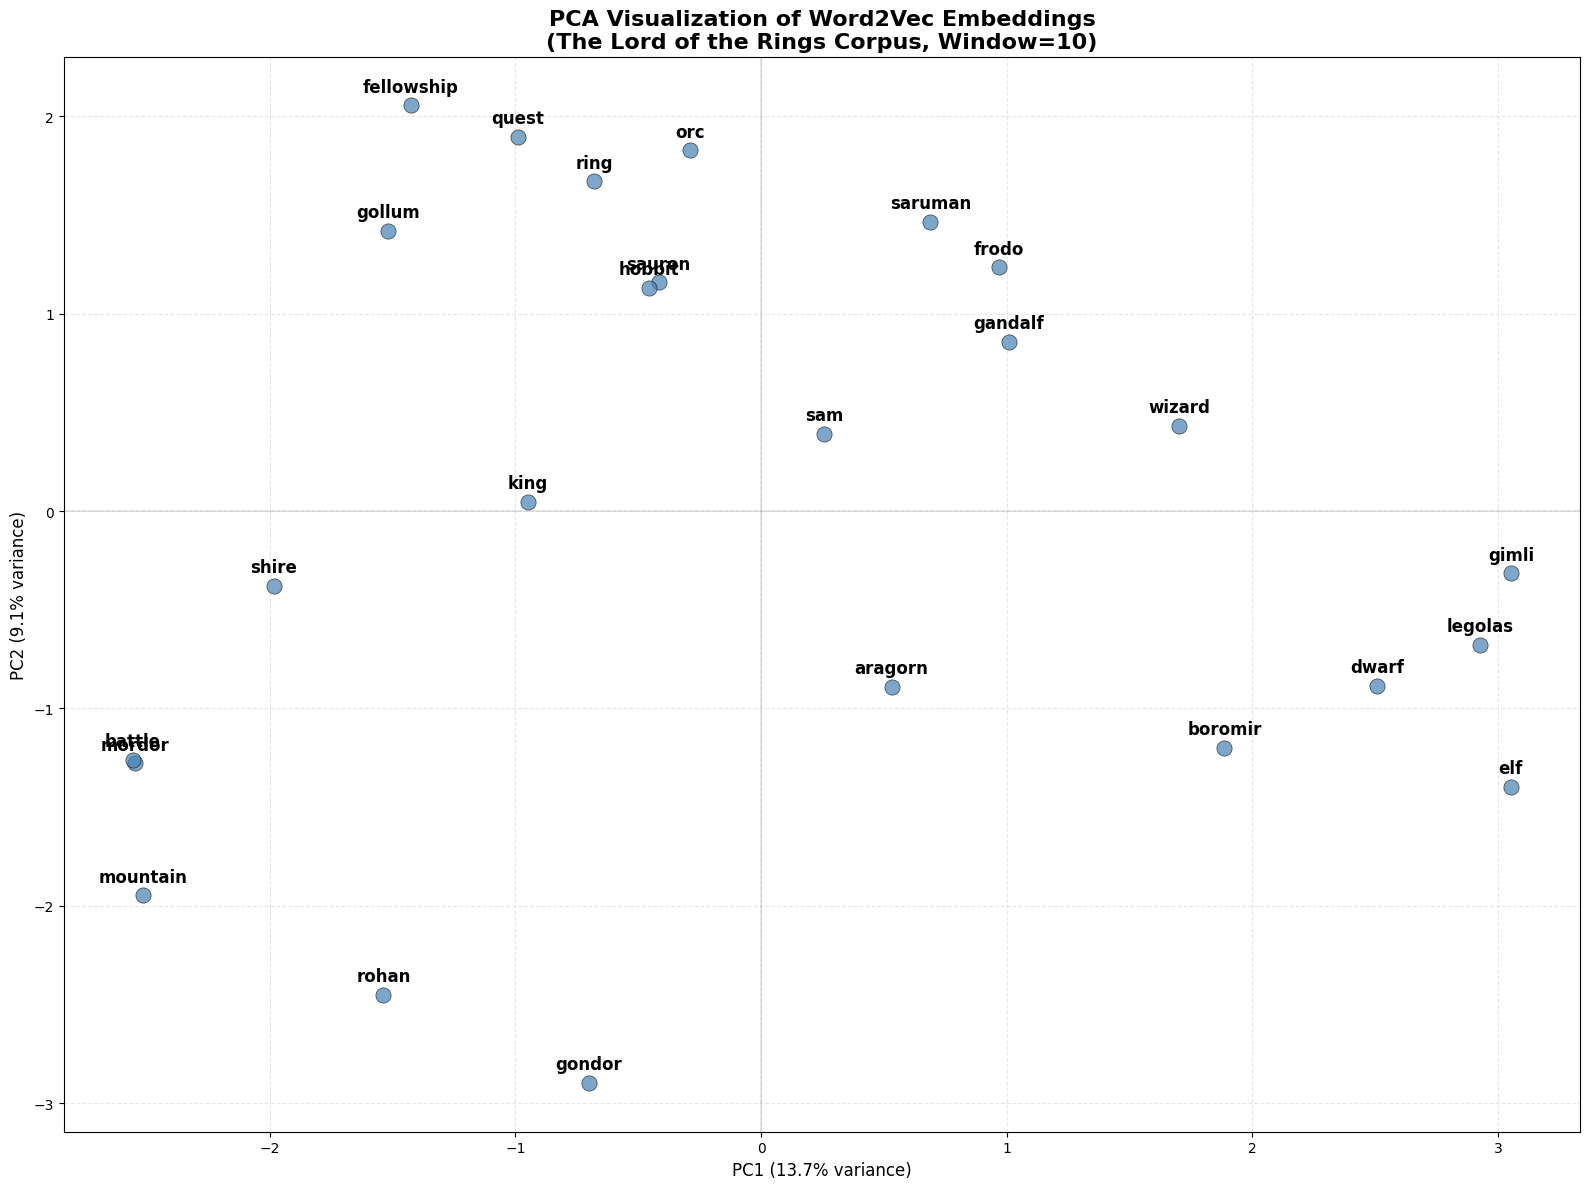


PCA Explained Variance:
  PC1: 13.74%
  PC2: 9.12%
  Total: 22.86%

Saved figure to: pca_lotr_embeddings.png


In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# At least 20 known LOTR words
words_to_plot = [
    "frodo", "sam", "gandalf", "aragorn", "legolas",
    "gimli", "boromir", "sauron", "saruman", "gollum",
    "ring", "shire", "mordor", "rohan", "gondor",
    "hobbit", "elf", "dwarf", "orc", "wizard",
    "king", "battle", "quest", "fellowship", "mountain"
]

# Filter to only words that exist in the model
available_words = [w for w in words_to_plot if has_word(model_new, w)]
print(f"Plotting {len(available_words)} words: {available_words}")

# Get vectors
vectors = np.array([model_new.wv[w] for w in available_words])

# Apply PCA to reduce to 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(16, 12))
plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.7, s=120, c='steelblue', edgecolors='black', linewidth=0.5)

# Annotate each point
for i, word in enumerate(available_words):
    plt.annotate(word, (reduced[i, 0], reduced[i, 1]),
                 fontsize=12, ha='center', va='bottom',
                 xytext=(0, 7), textcoords='offset points',
                 fontweight='bold')

plt.title("PCA Visualization of Word2Vec Embeddings\n(The Lord of the Rings Corpus, Window=10)", fontsize=16, fontweight='bold')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.2)
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.2)
plt.tight_layout()

# Save the figure
plt.savefig("pca_lotr_embeddings.png", dpi=200, bbox_inches='tight')
plt.show()

print(f"\nPCA Explained Variance:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"  Total: {sum(pca.explained_variance_ratio_):.2%}")
print(f"\nSaved figure to: pca_lotr_embeddings.png")

In [ ]:
# Download the saved models and figure
from google.colab import files

print("Downloading files...")
files.download("exercise_5_skipgram_window5.model")
files.download("exercise_5_skipgram_window10.model")
files.download("pca_lotr_embeddings.png")
print("Done! Check your downloads.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! Check your downloads.
